# Part 1 - Ex 1: SVM

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Loading the Dataset

In [2]:
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

print(X.shape)
print(f"Target classes: {np.unique(y)}")

(178, 13)
Target classes: [0 1 2]


In [3]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

## Splitting and Feature Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,  stratify=y)

print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Effect of Scaling

In [9]:
svm_unscaled = SVC(kernel='rbf', C=1, random_state=42)
svm_scaled   = SVC(kernel='rbf', C=1, random_state=42)

svm_unscaled.fit(X_train, y_train)
svm_scaled.fit(X_train_scaled, y_train)

acc_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))
acc_scaled   = accuracy_score(y_test, svm_scaled.predict(X_test_scaled))

print(f'Accuracy WITHOUT scaling: {acc_unscaled:.4f}')
print(f'Accuracy WITH    scaling: {acc_scaled:.4f}')

Accuracy WITHOUT scaling: 0.6667
Accuracy WITH    scaling: 0.9815


### Kernel Comparison

In [10]:
svm_lin = SVC(kernel='linear', C=1, random_state=42)
svm_rbf   = SVC(kernel='rbf', C=1, random_state=42)

svm_lin.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_lin = accuracy_score(y_test, svm_lin.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f'Accuracy using linear kernel: {acc_lin:.4f}')
print(f'Accuracy using rbf kernel: {acc_rbf:.4f}')

Accuracy using linear kernel: 0.9630
Accuracy using rbf kernel: 0.9815


## Training and Hyperparameter Tuning

In [11]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf'],
    'decision_function_shape': ['ovr', 'ovo'] # Addressing step 4 explicitly
}

In [12]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)

In [13]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'decision_function_shape': ['ovr', 'ovo'],
                         'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf']},
             verbose=1)

In [14]:
grid.best_params_

{'C': 1, 'decision_function_shape': 'ovr', 'gamma': 0.1, 'kernel': 'rbf'}

In [15]:
y_pred = grid.predict(X_test_scaled)

In [16]:
print(classification_report(y_test, y_pred, target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### 1. What is your best test metric to use in this case? And why?
*   **Answer:** The **F1-Score** (specifically the Weighted or Macro Average).
*   **F1-Score** is  the "best" because it provides a balance between **Precision** (avoiding false positives) and **Recall** (avoiding false negatives) for all three categories of wine. Since the model achieved a perfect performance, it shows the classes are very distinct after scaling.
* 	The Wine dataset has 3 classes with a mild class imbalance (59 / 71 / 48 samples). Accuracy alone can be misleading because a model that over-predicts the majority class still achieves high accuracy.

### 2. Which kernel performed best?
*   **Answer:** The **RBF kernel**. 
*   The RBF kernel performed slightly better than the linear kernel, with a CV F1-macro avg of 0.98 at the best C and gamma.
*   The Wine dataset is high-dimensional (13 features) but the classes are *not* probably *perfectly* linearly separable in the high dimension.
*   The RBF kernel maps the observations into a higher-dimensional feature space where a hyperplane can more cleanly separate the classes.

### 3. How did scaling affect performance?
*   SVM works by calculating the **distance** between data points to find the maximum margin.
*   Without scaling the RBF SVM accuracy dropped significantly (0.66), while with StandardScaler it reached near-perfect accuracy.
*   Features like `proline` (range 278–1680) would completely dominate features like color_intensity (range 0.41–3.58) without scaling.

# Part 1 - Ex 2: SVR

## Loading the Dataset

In [17]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X_h = housing.data
y_h = housing.target

print(X_h.shape)

(20640, 8)


In [18]:
df_h = pd.DataFrame(X_h, columns=housing.feature_names)
df_h['target'] = y_h
df_h.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [19]:
df_h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [20]:
df_h.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Splitting and Feature Scaling

In [21]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

In [22]:
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

## Training and Hyperparameter Tuning

In [23]:
from sklearn.svm import SVR

In [24]:
X_subset = X_train_h_scaled[:3000]
y_subset = y_train_h[:3000]

In [40]:
param_grid_svr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1]
}

In [41]:
grid_svr = GridSearchCV(SVR(), param_grid_svr, refit=True, verbose=1, cv=3)
grid_svr.fit(X_subset, y_subset)

Fitting 3 folds for each of 90 candidates, totalling 270 fits


GridSearchCV(cv=3, estimator=SVR(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'epsilon': [0.01, 0.1, 0.2],
                         'gamma': ['scale', 0.01, 0.1],
                         'kernel': ['linear', 'rbf']},
             verbose=1)

In [42]:
grid_svr.best_params_

{'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}

In [43]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

y_pred_h = grid_svr.predict(X_test_h_scaled)

mse = mean_squared_error(y_test_h, y_pred_h)
r2 = r2_score(y_test_h, y_pred_h)
mae = mean_absolute_error(y_test_h, y_pred_h)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Squared Error (MSE): 0.3520
R-squared Score (R2): 0.7314
Mean Absolute Error (MAE): 0.4037
Root Mean Squared Error (RMSE): 0.5933


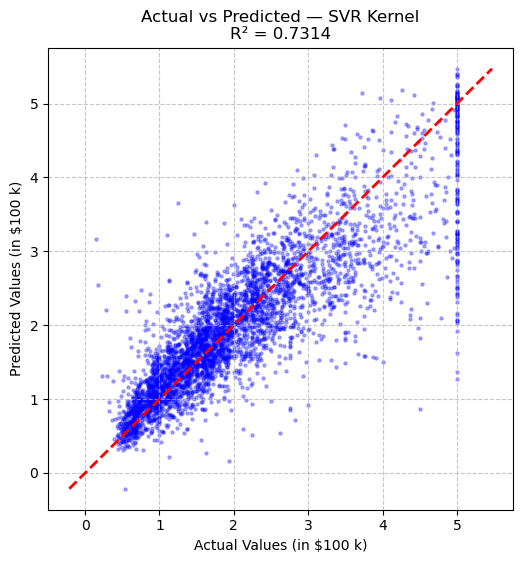

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_h, y_pred_h, alpha=0.3, color='blue', s=5)

min_val = min(np.min(y_test_h), np.min(y_pred_h))
max_val = max(np.max(y_test_h), np.max(y_pred_h))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax.set_xlabel('Actual Values (in $100 k)')
ax.set_ylabel('Predicted Values (in $100 k)')
ax.set_title(f"Actual vs Predicted — SVR Kernel\nR² = {r2:.4f}")
ax.grid(True, linestyle='--', alpha=0.7)

### 1. What is your best metric? and why?
*   **Answer:** **RMSE** and **R-squared Score ($R^2$)**.
*   **RMSE** is the primary metric for this regression task. Housing prices are right-skewed and contain outliers (capped at \$500k in this dataset). RMSE penalizes large errors more heavily than MAE.
*   RMSE is also in the same units as the target (hundred-thousands of dollars), making it more interpretable.
* **$R^2$ is also a good metric** here because it is a standardized value between 0 and 1. Our result of **0.7314** tells that the best model explains about **73% of the variance** in California house prices. We can use this metric regardless the target variable's unit. 

### 2. Which kernel worked best?
*   **Answer:** The **RBF (Radial Basis Function) kernel**.
*   Just like the Wine dataset, the relationship between house prices and features like geography (latitude/longitude) or population is highly complex and non-linear. The RBF kernel allows the model to capture these non-linear relationship in the data more effectively.

### 3. How did scaling affect performance?
*   Scaling ensures that every feature contributes equally to the distance calculation.
*   SVR in this context calculates the **distance** between data points to fit a high dimensional "tube" around the data. In this dataset, some features like `Population` have values in the thousands, while `AveRooms` are small numbers. Without scaling, the SVR would view the `Population` feature as significantly more important.

# Part 2 - Reflection & Summary

### Reflection

**What I learned about SVM**

*   The most important thing I learned from this exercise is that SVMs are sensitive to feature scaling and hyperparameter choices. On the Wine classification task, an RBF SVM without scaling achieved only ~65% accuracy, while the scaled version acheived almost a perfect accuracy.
*   The SVM margin is defined in terms of Euclidean distances and features on different scales will dominate that geometry entirely.
*   The kernel trick is powerful. By projecting data into a higher dimension where classes become linearly separable, the SVM avoids the computational explosion of explicitly constructing polynomial or radial features.
*   However, unlike a decision tree, there is no intuitive explanation for why a particular support vector was chosen.
*   Tuning C and gamma was expensive; even a moderate GridSearch over 5 combinations × 5 folds took noticeable wall-clock time on only 2000 housing samples, which confirms that SVMs scale poorly (O(n²) to O(n³) in training complexity).

**When might ensemble methods be more beneficial than SVM?**

*   Ensemble methods, particularly gradient-boosted trees (XGBoost, LightGBM) and Random Forests, are generally preferable over SVMs in several real-world scenarios.
*   On large datasets SVMs become computationally expensive while gradient boosting scales linearly or near-linearly.
*   Tree-based ensembles are can handle multi-class targets, require no scaling, and also handle mixed feature types, none of which SVMs do natively.
*   Tree ensembles offer built-in feature importance scores, making them more interpretable for business stakeholders.

**Observations & Surprises**

*   The classification task on the wine dataset was almost "too easy" once features were scaled. When I used a 80-20 split, the models achieved almost perfect accuracy. The Wine dataset is relatively low-noise and the three cultivars are chemically distinct, so even a linear SVM achieved near-perfect results.
*   In regression, performance was worse than initially expected, an $R^2$ around 0.73 on California Housing suggests SVR captures the broad trend but misses complex spatial and interaction effects that tree ensembles handle more naturally.
*   Finally, the tuning cost was noticeably higher for SVR than for the classifier, confirming that SVMs are best reserved for problems where dataset size is manageable.